<a href="https://colab.research.google.com/github/jostina/Week-1-2-Data-Cleaning-Exploratory-Data-Analysis/blob/main/Week_3_Statistics_%26_Probability_Housing_Dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Dataset
df = pd.read_csv("/content/Housing_Cleaned.csv")

In [ ]:
# Display first rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
# Select Numerical Columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("\nNumerical Columns:")
print(numeric_cols)



Numerical Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')


# 1. Descriptive Statistics

In [ ]:
# Mean
means = df[numeric_cols].mean()
print("\nMean:")
print(means)


Mean:
price        4.766729e+06
area         5.150541e+03
bedrooms     2.965138e+00
bathrooms    1.286239e+00
stories      1.805505e+00
parking      6.935780e-01
dtype: float64


In [ ]:
# Variance
variances = df[numeric_cols].var()
print("\nVariance:")
print(variances)


Variance:
price        3.498544e+12
area         4.709512e+06
bedrooms     5.447383e-01
bathrooms    2.524757e-01
stories      7.525432e-01
parking      7.423300e-01
dtype: float64


In [ ]:
# Standard Deviation
std_devs = df[numeric_cols].std()
print("\nStandard Deviation:")
print(std_devs)


Standard Deviation:
price        1.870440e+06
area         2.170141e+03
bedrooms     7.380639e-01
bathrooms    5.024696e-01
stories      8.674925e-01
parking      8.615858e-01
dtype: float64


In [ ]:
# Summary Statistics
print("\nSummary Statistics:")
print(df[numeric_cols].describe())


Summary Statistics:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


# 2. Probability Distributions

In [ ]:
# Skewness of numerical variables
skewness = df[numeric_cols].skew()

print("\nSkewness:")
print(skewness)


Skewness:
price        1.212239
area         1.321188
bedrooms     0.495684
bathrooms    1.589264
stories      1.082088
parking      0.842062
dtype: float64


In [ ]:
# Interpret skewness
for col in numeric_cols:
    if skewness[col] > 0.5:
        print(f"{col}: Positively skewed")
    elif skewness[col] < -0.5:
        print(f"{col}: Negatively skewed")
    else:
        print(f"{col}: Approximately normally distributed")


price: Positively skewed
area: Positively skewed
bedrooms: Approximately normally distributed
bathrooms: Positively skewed
stories: Positively skewed
parking: Positively skewed


In [ ]:
# Histogram for Sale Price
if 'price' in df.columns:
    target = 'price'
elif 'Price' in df.columns:
    target = 'Price'
elif 'MEDV' in df.columns:
    target = 'MEDV'
else:
    target = numeric_cols[-1]

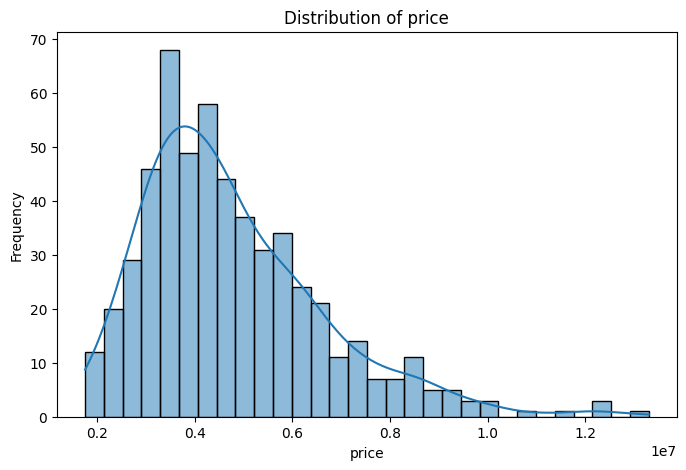

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df[target], bins=30, kde=True)
plt.title(f"Distribution of {target}")
plt.xlabel(target)
plt.ylabel("Frequency")
plt.show()


# 3. Hypothesis Testing

In [ ]:
if 'furnishingstatus' in df.columns:

    furnished = df[df['furnishingstatus'] == 'furnished'][target]
    semi_furnished = df[df['furnishingstatus'] == 'semi-furnished'][target]

    t_stat, p_value = stats.ttest_ind(
        furnished,
        semi_furnished,
        equal_var=False
    )

    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.6f}")



T-statistic: 2.8276
P-value: 0.005093


In [ ]:
alpha = 0.05

if 'furnishingstatus' in df.columns:
    if p_value < alpha:
        print("Reject the Null Hypothesis")
        print("Furnishing status significantly affects house price.")
    else:
        print("Fail to Reject the Null Hypothesis")
        print("Furnishing status does not significantly affect house price.")
else:
    print("Categorical column for hypothesis testing not found.")

Reject the Null Hypothesis
Furnishing status significantly affects house price.


# 4. Correlation vs Causation

In [ ]:
correlation_matrix = df[numeric_cols].corr()

# Correlation with target variable
print(f"\nCorrelation with {target}:")
print(
    correlation_matrix[target]
    .sort_values(ascending=False)
)



Correlation with price:
price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


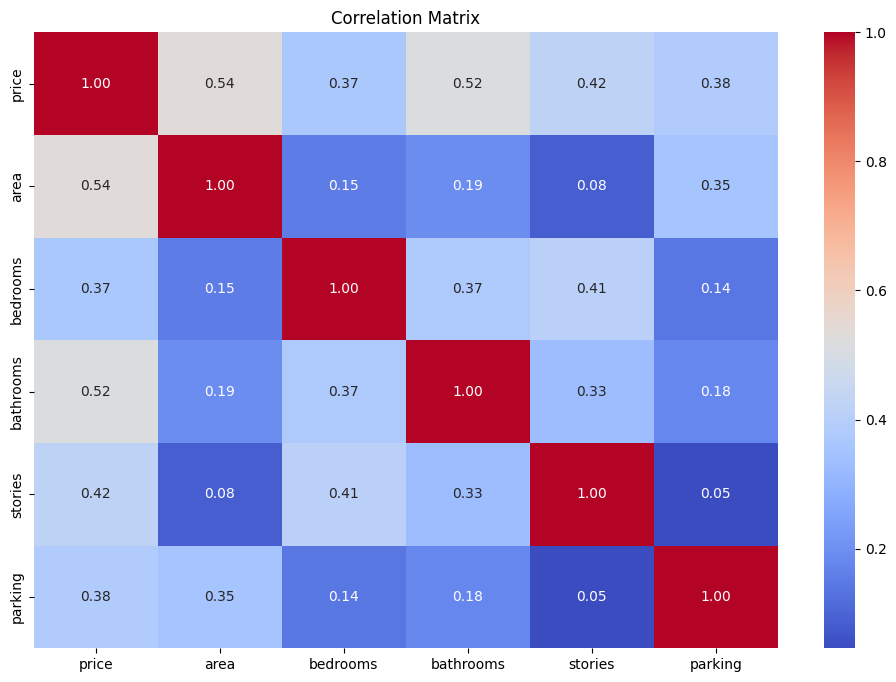

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()